In [ ]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from pathlib import Path



functions

In [11]:
def lbt_aperture(delta_spacing, n_pix, d):
    '''
    Generate the two-aperture LBT pupil (SX (left) + DX (right)): 
    8.25 m diameter mirrors, with 14.4 m center-to-center separation

    INPUTS:
    delta_spacing (float): pixel size in the aperture image, in meters
    n_pix (int): number of pixels across the aperture
    d (float): diameter of the mirrors, in meters (usually 8.25)

    OUTPUTS:
    sx_aperture (array): boolean array of the SX aperture
    dx_aperture (array): boolean array of the DX aperture
    lbt_pupil (array): boolean array of the full LBT aperture
    xx (array): pupil x-coordinates in meters
    yy (array): pupil y-coordinates in meters
    '''

    # padding
    pad_factor = n_pix * delta_spacing / d

    # initialize meshgrid to set distances
    x_pos = np.arange(-d / 2.0 * pad_factor, d / 2.0 * pad_factor, delta_spacing)
    y_pos = np.arange(-d / 2.0 * pad_factor, d / 2.0 * pad_factor, delta_spacing)
    xx, yy = np.meshgrid(x_pos, y_pos)

    # set distances of the two subapertures
    xx_dx = xx - 7.2085
    xx_sx = xx + 7.2085

    # create boolean arrays that define the apertures
    r_sx = np.sqrt(xx_sx**2 + yy**2)
    r_dx = np.sqrt(xx_dx**2 + yy**2)
    sx_aperture = r_sx < d / 2.0
    dx_aperture = r_dx < d / 2.0
    lbt_pupil = sx_aperture + dx_aperture

    return sx_aperture, dx_aperture, lbt_pupil, xx, yy

def make_psf(sx_aperture, dx_aperture, piston_waves, wavel, tip_asec, tilt_asec, xx, yy):
    '''
    Complex focal-plane amplitude from the LBT pupil plus OPD and tip/tilt.

    INPUTS:
    sx_aperture (array): boolean array of the SX aperture
    dx_aperture (array): boolean array of the DX aperture
    piston_waves (float): DX piston in waves (OPD / wavelength)
    wavel (float): wavelength in meters
    tip_asec (float): tip in arcseconds (applied to DX only)
    tilt_asec (float): tilt in arcseconds (applied to DX only)
    xx (array): pupil x-coordinates in meters
    yy (array): pupil y-coordinates in meters

    OUTPUTS:
    focal_field (array): complex focal-plane amplitude
    pupil_field (array): complex pupil field
    '''

    # DX centroid (m); tip/tilt OPD is zero there so piston stays in piston_waves
    x_dx_cen = np.mean(xx[dx_aperture])
    y_dx_cen = np.mean(yy[dx_aperture])

    # wavefront tilt in radians (sky angle)
    tip_rad = tip_asec / 206265
    tilt_rad = tilt_asec / 206265

    # tip/tilt OPD in meters, then waves; SX is the phase reference
    opd_tip_tilt = (yy - y_dx_cen) * tip_rad + (xx - x_dx_cen) * tilt_rad
    tip_tilt_waves = opd_tip_tilt / wavel

    sx_field = np.multiply(1.0, sx_aperture)
    dx_field = np.multiply(
        dx_aperture, np.exp(1.j * 2 * np.pi * np.add(piston_waves, tip_tilt_waves))
    )

    # put the two subapertures together
    pupil_field = sx_field + dx_field

    # Fourier transform the pupil field to get the focal-plane amplitude
    focal_field = np.fft.fft2(pupil_field)
    focal_field = np.fft.fftshift(focal_field)

    return focal_field, pupil_field

def make_intensity(opd, tip_asec, tilt_asec, wavel=3.7e-6, n_pix=2048, d=8.25, ps_lmir=0.0107):
    '''
    Monochromatic intensity, as seen on the detector, for a given OPD (m) and differential tip/tilt (asec).

    INPUTS:
    opd (float): optical path difference in meters
    tip_asec (float): tip in arcseconds
    tilt_asec (float): tilt in arcseconds
    wavel (float): wavelength in meters (default: 3.7 um)
    n_pix (int): number of pixels across the aperture; this is not the detector itself,
        but rather an image of the aperture (default: 2048)
    d (float): diameter of the mirrors in meters (default: 8.25)
    ps_lmir (float): detector plate scale in arcsec/pixel (default: 0.0107)

    OUTPUTS:
    intensity (array): intensity in the detector plane
    pupil_phase (array): wrapped pupil phase in radians
    '''

    # pupil sampling that makes the FFT plate scale equal ps_lmir
    delta_spacing = (206265 / (n_pix * ps_lmir)) * wavel

    # get the apertures
    sx_aperture, dx_aperture, _, xx, yy = lbt_aperture(delta_spacing, n_pix, d)

    piston_waves = opd / wavel
    focal_field, pupil_field = make_psf(
        sx_aperture, dx_aperture, piston_waves, wavel, tip_asec, tilt_asec, xx, yy
    )

    # generate the intensity on detector
    intensity = np.real(focal_field * np.conj(focal_field))

    # wrapped pupil phase for plotting (masked outside the apertures)
    pupil_phase = np.angle(pupil_field)
    pupil_phase = np.ma.masked_where(np.abs(pupil_field) == 0, pupil_phase)

    return intensity, pupil_phase

def crop_center(img, half=80):
    '''
    Crop to the center of the image where the PSF is.

    INPUTS:
    img (array): image to crop
    half (int): half the size of the cropped image

    OUTPUTS:
    cropped_img (array): cropped image
    '''

    cy, cx = np.array(img.shape) // 2

    # crop the image
    return img[cy - half:cy + half, cx - half:cx + half]

varying OPD

Text(0, 0.5, 'OPD (um)')

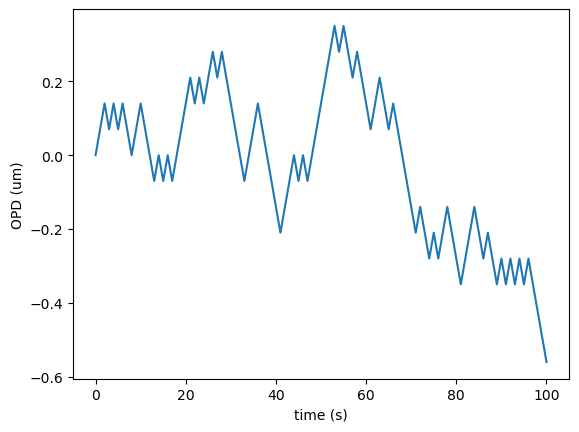

In [40]:
#varying phase

N = 100

OPD_range = np.array([-0.07, 0.07]) #micrometers
random_steps = np.random.choice(OPD_range, size=N)

varied_OPD = np.concatenate([[0], np.cumsum(random_steps)])

plt.plot(varied_OPD)
plt.xlabel('time (s)')
plt.ylabel('OPD (um)')

In [38]:
intensities = []
phase_pupils = []

for opd in varied_OPD:
    intensity, phase_pupil  = make_intensity(opd=opd, tilt_asec=0, tip_asec=0, wavel=3.7e-6, n_pix=2048, d=8.25, ps_lmir=0.0107)
    intensities.append(crop_center(intensity, half=30))
    phase_pupils.append(phase_pupil)


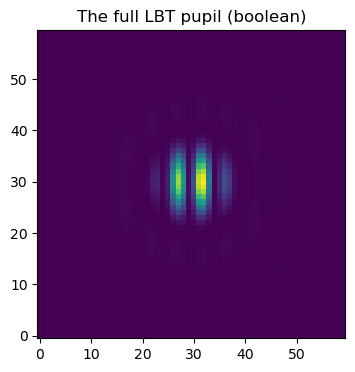

In [25]:
fig, axes = plt.subplots(1, 1, figsize=(4, 4))
axes.imshow(intensities[60], origin="lower")
axes.set_title("The full LBT pupil (boolean)")
plt.show()

In [ ]:
#make fits files



output_dir = Path("simulated_images_varied_OPD")
output_dir.mkdir(exist_ok=True)

for k, intensity in enumerate(intensities):
    hdu = fits.PrimaryHDU(data=intensity)
    hdu.header['OPD'] = (varied_OPD[k], 'OPD in mircometers')


    filename = output_dir / f"varied_OPD_image{k}.fits"
    hdu.writeto(filename, overwrite=True)


varying tip and tilt

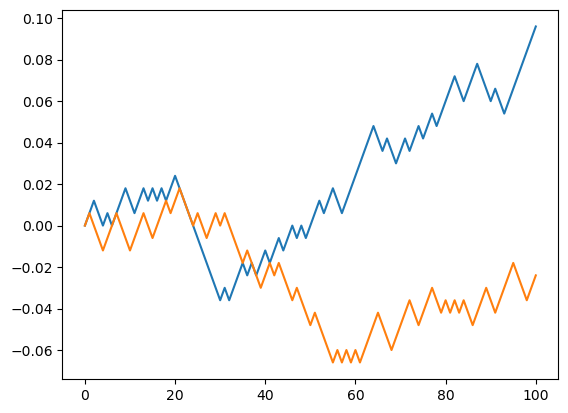

In [28]:
N = 100

tilt_tip_range = np.array([-0.006, 0.006]) #arcsec
random_steps_tilt = np.random.choice(tilt_tip_range, size=N)
random_steps_tip = np.random.choice(tilt_tip_range, size=N)

varied_tilt = np.concatenate([[0], np.cumsum(random_steps_tilt)])
varied_tip = np.concatenate([[0], np.cumsum(random_steps_tip)])

plt.plot(varied_tilt)
plt.plot(varied_tip)

In [30]:
intensities = []
phase_pupils = []

for tilt, tip in zip(varied_tilt, varied_tip):
    intensity, phase_pupil  = make_intensity(opd=0, tilt_asec=tilt, tip_asec=tip, wavel=3.7e-6, n_pix=2048, d=8.25, ps_lmir=0.0107)
    intensities.append(crop_center(intensity, half=30))
    phase_pupils.append(phase_pupil)

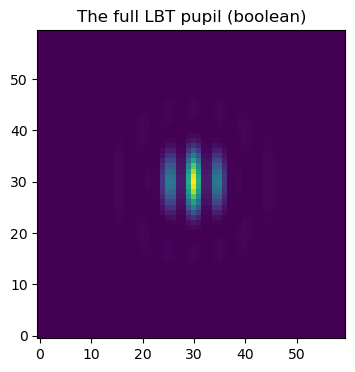

101


In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(4, 4))
axes.imshow(intensities[0], origin="lower")
axes.set_title("The full LBT pupil (boolean)")
plt.show()


In [ ]:
#make fits files

from pathlib import Path

output_dir = Path("simulated_images_varied_tip_and_tilt")
output_dir.mkdir(exist_ok=True)

for k, intensity in enumerate(intensities):
    hdu = fits.PrimaryHDU(data=intensity)
    hdu.header['TILT'] = (varied_tilt[k], 'differential tilt in arcseconds')
    hdu.header['TIP'] = (varied_tip[k], 'differential tip in arcseconds')
    
    filename = output_dir / f"varied_tip_tilt_OPD_image{k}.fits"
    hdu.writeto(filename, overwrite=True)


varying OPD, tip and tilt

In [41]:
N=100

OPD_range = np.array([-0.07, 0.07]) #micrometers
random_steps = np.random.choice(OPD_range, size=N)

varied_OPD = np.concatenate([[0], np.cumsum(random_steps)])

tilt_tip_range = np.array([-0.006, 0.006]) #arcsec
random_steps_tilt = np.random.choice(tilt_tip_range, size=N)
random_steps_tip = np.random.choice(tilt_tip_range, size=N)

varied_tilt = np.concatenate([[0], np.cumsum(random_steps_tilt)])
varied_tip = np.concatenate([[0], np.cumsum(random_steps_tip)])


In [42]:
intensities = []
phase_pupils = []

for tilt, tip, opd in zip(varied_tilt, varied_tip, varied_OPD):
    intensity, phase_pupil  = make_intensity(opd=opd, tilt_asec=tilt, tip_asec=tip, wavel=3.7e-6, n_pix=2048, d=8.25, ps_lmir=0.0107)
    intensities.append(crop_center(intensity, half=30))
    phase_pupils.append(phase_pupil)

In [43]:
output_dir = Path("simulated_images_varied_tip_tilt_opd")
output_dir.mkdir(exist_ok=True)

for k, intensity in enumerate(intensities):
    hdu = fits.PrimaryHDU(data=intensity)
    hdu.header['TILT'] = (varied_tilt[k], 'differential tilt in arcseconds')
    hdu.header['TIP'] = (varied_tip[k], 'differential tip in arcseconds')
    hdu.header['OPD'] = (varied_OPD[k], 'OPD in micrometers')
    
    filename = output_dir / f"varied_OPD_image{k}.fits"
    hdu.writeto(filename, overwrite=True)
